<a href="https://colab.research.google.com/github/roshika1235/IPL_Crushes_Hackathon/blob/main/IPL_crushes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA ANALYSIS ON IPL 2026

## Importing all necessary libraries

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and read the data

In [140]:
df=pd.read_csv("/content/cric_info.csv")
df
df.info()

/tmp/ipykernel_738/3335699720.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/cric_info.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  object 
 2   season             289673 non-null  object 
 3   event              289673 non-null  object 
 4   venue              289673 non-null  object 
 5   city               277276 non-null  object 
 6   team1              289673 non-null  object 
 7   team2              289673 non-null  object 
 8   toss_winner        289673 non-null  object 
 9   toss_decision      289673 non-null  object 
 10  winner             289673 non-null  object 
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  object 
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  object 
 16  ov

## Step 1: Data Cleaning

In [141]:
# 1st 5 columns

#0 match_id
df['match_id'].unique()

#1 date
df['date'].unique()
df['date']=pd.to_datetime(df['date'])   ## changing it into proper datatype

#2 season
df['season'].unique()
df['season']=df['season'].astype(str)
df = df[~df['season'].str.contains('2007')]
df['season']=df['season'].str.split('/').str[0]
df['season']=df['season'].astype(int)
df['season'].unique()

#3 event
df['event'].unique()

#4 venue
df['venue'].unique()


array(['Rajiv Gandhi International Stadium, Uppal',
       'Maharashtra Cricket Association Stadium',
       'Saurashtra Cricket Association Stadium', 'Holkar Cricket Stadium',
       'M.Chinnaswamy Stadium', 'Wankhede Stadium', 'Eden Gardens',
       'M Chinnaswamy Stadium', 'Feroz Shah Kotla',
       'Punjab Cricket Association IS Bindra Stadium, Mohali',
       'Green Park', 'Punjab Cricket Association IS Bindra Stadium',
       'Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium',
       'Sawai Mansingh Stadium', 'Arun Jaitley Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Sheikh Zayed Stadium', 'Dubai International Cricket Stadium',
       'Sharjah Cricket Stadium',
       'MA Chidambaram Stadium, Chepauk, Chennai',
       'Wankhede Stadium, Mumbai', 'Narendra Modi Stadium, Ahmedabad',
       'Arun Jaitley Stadium, Delhi', 'Zayed Cricket Stadium, Abu Dhabi',
       'Brabourne Stadium, Mumbai', 'Dr DY Patil Sports Academy, Mumbai',
       

In [142]:
# 2nd set of 5 columns

#5 city
df['city'].unique()
df=df.dropna(subset=['city'])
df['city'].unique()

#6 team1
df['team1'].unique()

#7 team2
df['team2'].unique()

#8 toss_winner
df['toss_winner'].unique()

#9 toss_decision
df['toss_decision'].unique()


array(['field', 'bat'], dtype=object)

In [143]:
# 3rd set of 5 columns

#10 winner
df['winner'].unique()

#11 win_by_runs
df['win_by_runs'].unique()

#12 win_by_wickets
df['win_by_wickets'].unique()
df=df.dropna(subset=['win_by_wickets'])
df['win_by_wickets']=df['win_by_wickets'].astype(int)
df['win_by_wickets'].unique()

#13 player_of_match
df['player_of_match'].unique()

#14 innings
df['innings'].unique()

array([1, 2])

In [144]:
# remaining columns

#15 batting team
df['batting_team'].unique()

#16 over
df['over'].unique()

#17 ball
df['ball'].unique()

#18 batsman
df['batter'].unique()

#19 bowler
df['bowler'].unique()

#20 non_striker
df['non_striker'].unique()

#21 runs_batter
df['runs_batter'].unique()

#22 runs_extras
df['runs_extras'].unique()

#23 runs_total
df['runs_total'].unique()
df['runs_total'] = pd.to_numeric(df['runs_total'], errors='coerce')

#24 extras_wides
df['extras_wides'].unique()

#25 extras_noballs
df['extras_noballs'].unique()

#26 extras_byes
df['extras_byes'].unique()

#27 extras_legbyes
df['extras_legbyes'].unique()

#28 wicket_kind
df['wicket_kind'].unique()

#29 wicket_player_out
df['wicket_kind'].unique()

array([nan, 'bowled', 'lbw', 'caught and bowled', 'caught', 'run out',
       'stumped', 'retired hurt', 'hit wicket', 'obstructing the field'],
      dtype=object)

## STEP 2: Data Analysis
## ANSWERING INSIGHTS



# Do teams that win the toss actually win more matches?

In [145]:
df['toss_and_match_win'] = df['toss_winner'] == df['winner']
df['toss_and_match_win'].value_counts()

,count
toss_and_match_win,
True,92675
False,44953


In [146]:
print("Percentage of win by winning the toss")
df['toss_and_match_win'].value_counts(normalize=True) * 100

Percentage of win by winning the toss


,proportion
toss_and_match_win,
True,67.337315
False,32.662685


# Chart 1 — two bars showing win rate of toss winners vs toss losers

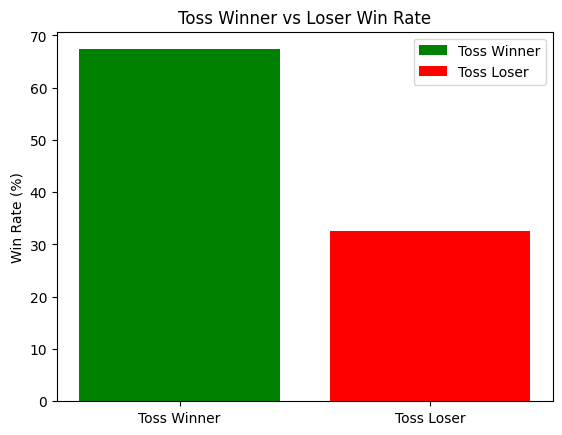

In [147]:
#Chart 1 — two bars showing win rate of toss winners vs toss losers

toss_win=df['toss_and_match_win'].mean()*100
toss_lose=100-toss_win
plt.bar('Toss Winner', toss_win, color='green', label='Toss Winner')
plt.bar('Toss Loser', toss_lose, color='red', label='Toss Loser')
plt.title('Toss Winner vs Loser Win Rate')
plt.ylabel('Win Rate (%)')
plt.legend()
plt.show()



INSIGHTS :
Winning the toss offers a significant statistical advantage because team management and captains carefully analyze venue-specific conditions. The nature of a pitch often changes dynamically between the two innings. Key factors influencing the toss decision include the dew factor (which makes gripping the ball difficult for bowlers in the second innings) and the soil type (such as slow black soil or spin-friendly red soil). Understanding these variables allows teams to optimize their strategies, decide whether to bat or bowl first, and exploit the shifting conditions to their advantage.

# Which phase — powerplay, middle overs, or death overs — is most linked to winning?

In [148]:
# Step 1: Compute runs per ball (all deliveries, not just wickets)
df['runs_on_ball'] = (
    df['runs_batter']
    + df['extras_wides']
    + df['extras_noballs']
    + df['extras_byes']
    + df['extras_legbyes']
)

# Step 2: Tag each delivery with its phase
def get_phase(over):
    if over < 6:
        return 'Powerplay'
    elif over < 16:
        return 'Middle Overs'
    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(get_phase)

# Step 3: Runs per match per batting team per phase
phase_runs = df.groupby(['match_id', 'batting_team', 'phase'])['runs_on_ball'].sum().reset_index()

# Step 4: Pull match-level winner info (one row per match)
match_winners = df[['match_id', 'winner']].drop_duplicates()

# Step 5: Merge so we know if the batting team won
phase_runs = phase_runs.merge(match_winners, on='match_id')
phase_runs['team_won'] = phase_runs['batting_team'] == phase_runs['winner']

# Step 6: Compare average phase runs — winners vs losers
phase_summary = phase_runs.groupby(['phase', 'team_won'])['runs_on_ball'].mean().unstack()
phase_summary.columns = ['Lost', 'Won']
phase_summary['Run Difference (Won - Lost)'] = phase_summary['Won'] - phase_summary['Lost']

print(phase_summary.sort_values('Run Difference (Won - Lost)', ascending=False))

                   Lost        Won  Run Difference (Won - Lost)
phase                                                          
Powerplay     44.982993  52.013605                     7.030612
Middle Overs  74.527211  80.680961                     6.153750
Death Overs   37.814236  31.396341                    -6.417895


# Chart 2 — average runs per phase for winning teams vs losing teams

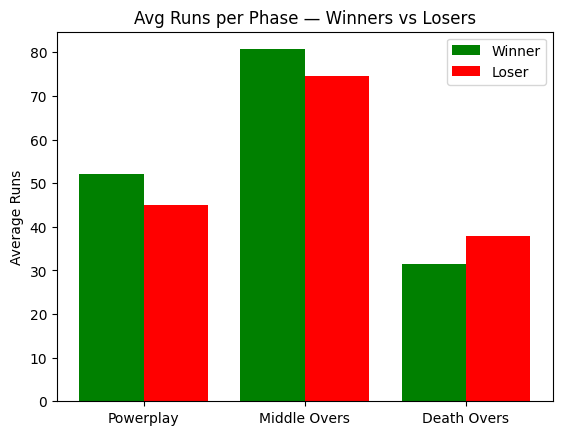

In [149]:
phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
won_avg  = phase_summary.loc[phase_order, 'Won'].values
lost_avg = phase_summary.loc[phase_order, 'Lost'].values

x = np.arange(len(phase_order))

plt.bar(x - 0.2, won_avg,  width=0.4, color='green', label='Winner')
plt.bar(x + 0.2, lost_avg, width=0.4, color='red',   label='Loser')

plt.xticks(x, phase_order)
plt.title('Avg Runs per Phase — Winners vs Losers')
plt.ylabel('Average Runs')
plt.legend()
plt.show()

INSIGHTS:

Teams that win the match , are taking advantage in powerplay to score high,
and maintaining good run rate in middle overs, then finishing the game in death overs.

# Who are the top 5 batters and top 5 bowlers across 5 seasons?

In [150]:
# Total runs scored by each batter (runs_batter excludes extras)
top_batters = (
    df.groupby('batter')['runs_batter']
    .sum()
    .reset_index()
    .rename(columns={'runs_batter': 'total_runs'})
    .sort_values('total_runs', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_batters.index += 1  # Rank starting from 1
print("🏏 Top 5 Batters across 5 seasons:")
print(top_batters)

🏏 Top 5 Batters across 5 seasons:
      batter  total_runs
1    V Kohli        4753
2   S Dhawan        3777
3  RG Sharma        3175
4   SK Raina        3049
5  DA Warner        2947


In [151]:
#TOP 5 BOWLERS

# A legal delivery = not a wide and not a no-ball
legal_df = df[(df['extras_wides'] == 0) & (df['extras_noballs'] == 0)]

# Total wickets per bowler
# wicket_kind has NaN where no wicket — only count actual dismissals
# Exclude run-outs (bowler doesn't get credit)
bowler_wickets = (
    df[df['wicket_kind'].notna() & (df['wicket_kind'] != 'run out')]
    .groupby('bowler')['wicket_kind']
    .count()
    .reset_index()
    .rename(columns={'wicket_kind': 'total_wickets'})
)

# Total runs conceded per bowler (legal balls only)
bowler_runs = (
    legal_df.groupby('bowler')['runs_on_ball']
    .sum()
    .reset_index()
    .rename(columns={'runs_on_ball': 'runs_conceded'})
)

# Total legal balls bowled
bowler_balls = (
    legal_df.groupby('bowler')
    .size()
    .reset_index(name='balls_bowled')
)

# Merge everything, 1st total wickets to runs given by bowler and his legal bowls

bowlers_df = bowler_wickets.merge(bowler_runs, on='bowler').merge(bowler_balls, on='bowler')

# Economy rate = runs conceded per over (6 balls)
bowlers_df['economy'] = (bowlers_df['runs_conceded'] / bowlers_df['balls_bowled'] * 6).round(2)

top_bowlers = (
    bowlers_df.sort_values('total_wickets', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_bowlers.index += 1  # Rank starting from 1
print("Top 5 Bowlers across 5 seasons:")
print(top_bowlers[['bowler', 'total_wickets', 'runs_conceded', 'economy']])

Top 5 Bowlers across 5 seasons:
      bowler  total_wickets  runs_conceded  economy
1  SP Narine            108           2718     6.43
2  YS Chahal            106           2640     7.86
3    B Kumar            102           2700     7.47
4  RA Jadeja             93           3032     7.57
5   R Ashwin             87           2890     7.30


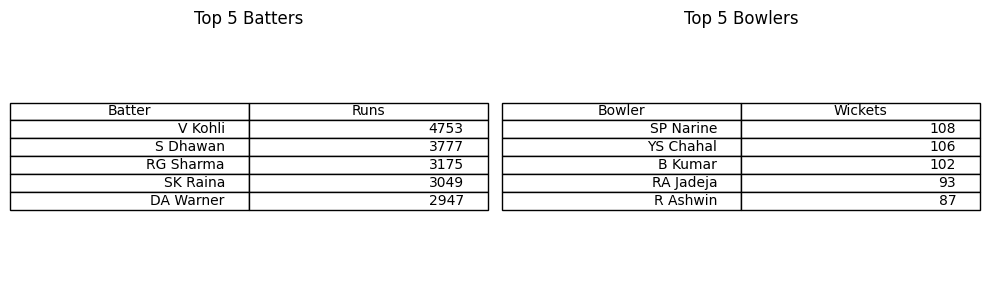

In [152]:


fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Top 5 Batters
axes[0].axis('off')
axes[0].table(
    cellText=top_batters[['batter', 'total_runs']].values,
    colLabels=['Batter', 'Runs'],
    loc='center'
)
axes[0].set_title('Top 5 Batters')

# Top 5 Bowlers
axes[1].axis('off')
axes[1].table(
    cellText=top_bowlers[['bowler', 'total_wickets']].values,
    colLabels=['Bowler', 'Wickets'],
    loc='center'
)
axes[1].set_title('Top 5 Bowlers')

plt.tight_layout()
plt.show()

this players are consistant through out that 5 seaons.

# One sentence — something the data showed you that genuinely surprised you

In [153]:
# Batters who score heavily in death overs only (finishers, not openers)
death = df[df['over'] >= 16].groupby('batter')['runs_batter'].sum()
power = df[df['over'] < 6].groupby('batter')['runs_batter'].sum()
finishers = (death - power).sort_values(ascending=False).head(5)
print(finishers)

batter
MS Dhoni      1227.0
KA Pollard     673.0
RA Jadeja      645.0
KD Karthik     594.0
AD Russell     575.0
Name: runs_batter, dtype: float64


Sometimes death over is also crucial, it is a phase where we feel that pressure, but coming last, and scoring more runs to something incredibly surprising, someday it might surpass the top 5 batters list also.